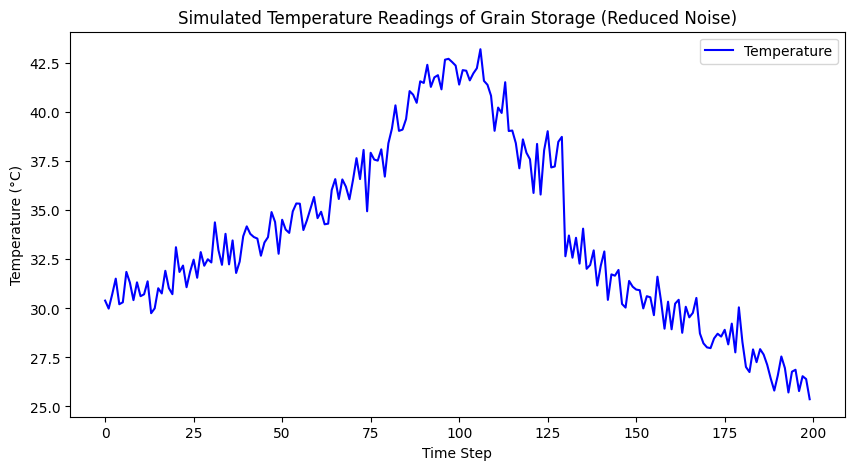

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
time_steps = 200
x = np.arange(time_steps)

# Create a base temperature trend with gradual changes
baseline_temp = 30 + np.sin(x / 50) * 5  # Slow variation over time

# Introduce a gradual peak and dip (simulating seasonal change)
seasonal_variation = np.exp(-(x - 100)**2 / 500) * 8  # Peak at t=100

# Reduce random temperature fluctuations (noise)
random_noise = np.random.normal(scale=0.8, size=time_steps)  # Lower noise level

# Simulating an unexpected rise in temperature (spoilage risk)
spike = np.zeros_like(x)
spike[120:130] = np.linspace(0, 5, 10)  # Gradual temperature increase in this range

# Combine all components to create realistic temperature data
y = baseline_temp + seasonal_variation + random_noise + spike

# Plot the generated time series data
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Temperature", color='b')
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.title("Simulated Temperature Readings of Grain Storage (Reduced Noise)")
plt.legend()
plt.show()


In [17]:
# Normalize the data
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        Y.append(data[i + seq_length])
    return np.array(X), np.array(Y)

seq_length = 10  # Number of past days used to predict the next day
X, Y = create_sequences(y_scaled, seq_length)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# Reshape for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [7]:
# Define LSTM model
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, Y_train, epochs=20, batch_size=16, validation_data=(X_test, Y_test))


Epoch 1/20


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.3512 - val_loss: 0.1330
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1994 - val_loss: 0.0418
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0384 - val_loss: 0.0317
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0277 - val_loss: 0.0330
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0320 - val_loss: 0.0297
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0281 - val_loss: 0.0290
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0297 - val_loss: 0.0282
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0278 - val_loss: 0.0273
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0248 - val_loss: 0.0266
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0248 - val_loss: 0.0258
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0263 - val_loss: 0.0242
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0245 - val_loss: 0.025

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


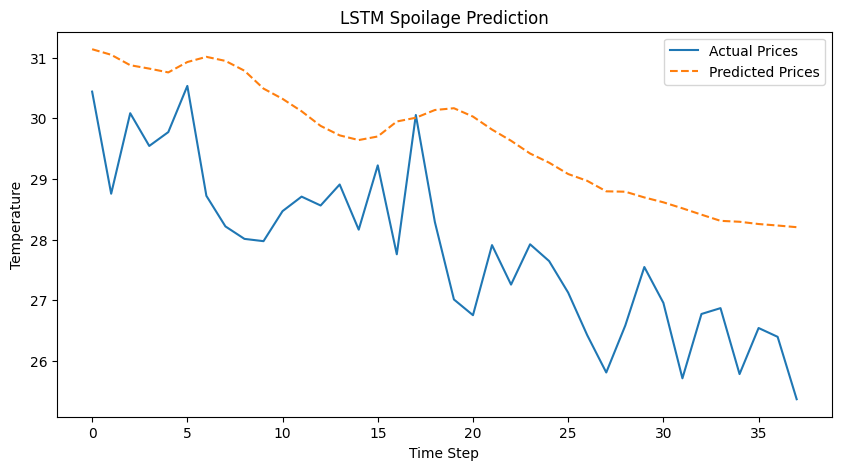

In [22]:
# Predict future stock prices
predictions = model.predict(X_test)

# Convert predictions back to original scale
predictions = scaler.inverse_transform(predictions)
Y_test_original = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(Y_test_original, label="Actual Prices")
plt.plot(predictions, label="Predicted Prices", linestyle="dashed")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.title("LSTM Spoilage Prediction")
plt.legend()
plt.show()


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute errors
mse = mean_squared_error(Y_test_original, predictions)
mae = mean_absolute_error(Y_test_original, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((Y_test_original - predictions) / Y_test_original)) * 100

# Print error values
print(f"Mean Square Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")


Mean Square Error (MSE): 3.9584359058652385
Mean Absolute Error (MAE): 1.822453674509319
Root Mean Square Error (RMSE): 1.9895818419620839
Mean Absolute Percentage Error (MAPE): 6.657259926185549%


In [21]:
from sklearn.metrics import r2_score

# SMAPE Calculation
def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

# Compute errors
mape = np.mean(np.abs((Y_test_original - predictions) / Y_test_original)) * 100
accuracy = 100 - mape  # Accuracy based on MAPE
r2 = r2_score(Y_test_original, predictions)
smape_value = smape(Y_test_original, predictions)

# Print accuracy metrics
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"Forecast Accuracy: {accuracy}%")
print(f"R-Squared Score (R²): {r2}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape_value}%")


Mean Absolute Percentage Error (MAPE): 6.657259926185549%
Forecast Accuracy: 93.34274007381445%
R-Squared Score (R²): -1.1653679838024025
Symmetric Mean Absolute Percentage Error (SMAPE): 6.400027146123896%


In [5]:
import pandas as pd
import numpy as np

# Define date range: hourly from Feb 1 to Apr 30
date_range = pd.date_range(start="2024-02-01", end="2024-04-30 23:00:00", freq='H')

# Lists to store generated data
temperatures = []
humidities = []
air_quality_values = []

# Generate synthetic data
for timestamp in date_range:
    month = timestamp.month
    hour = timestamp.hour

    # Temperature: warmer during the day, cooler at night
    if 6 <= hour <= 18:
        base_temp = np.random.uniform(30, 35)
    else:
        base_temp = np.random.uniform(25, 30)

    temp = base_temp + np.random.normal(0, 1.5)
    temperatures.append(round(temp, 2))

    # Humidity based on monthly trend
    if month == 2:
        base_humidity = np.random.uniform(50, 60)
    elif month == 3:
        base_humidity = np.random.uniform(45, 55)
    else:  # April
        base_humidity = np.random.uniform(55, 62)

    if 6 <= hour <= 18:
        base_humidity -= np.random.uniform(1, 3)

    humidity = base_humidity + np.random.normal(0, 1.2)
    humidity = round(max(20, min(humidity, 100)), 2)
    humidities.append(humidity)

    # Air Quality: values around 2587 with some noise
    air_quality = 2587 + np.random.normal(0, 80)  # mean 2587, std deviation 80
    air_quality = int(np.clip(air_quality, 2400, 2800))  # clamp values
    air_quality_values.append(air_quality)

# Create DataFrame
df2 = pd.DataFrame({
    "Timestamp": date_range,
    "Location_ID": "Room_1",
    "Temperature_C": temperatures,
    "Humidity_%": humidities,
    "Air_Quality_MQ135_raw": air_quality_values
})

# Save to CSV
df2.to_csv("three_month_data.csv", index=False)
print("CSV file 'three_month_data.csv' generated successfully.")
df2.head()


CSV file 'three_month_data.csv' generated successfully.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7372\3267193482.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start="2024-02-01", end="2024-04-30 23:00:00", freq='H')


,Timestamp,Location_ID,Temperature_C,Humidity_%,Air_Quality_MQ135_raw
0,2024-02-01 00:00:00,Room_1,25.93,54.06,2533
1,2024-02-01 01:00:00,Room_1,27.37,53.37,2557
2,2024-02-01 02:00:00,Room_1,27.77,51.97,2584
3,2024-02-01 03:00:00,Room_1,26.01,53.71,2527
4,2024-02-01 04:00:00,Room_1,28.91,55.85,2477


In [3]:
df2.head()


,Timestamp,Location_ID,Temperature_C,Humidity_%,Air_Quality_MQ135_raw
0,2024-02-01 00:00:00,Room_1,18.61,43.05,2527
1,2024-02-01 01:00:00,Room_1,8.83,43.04,2675
2,2024-02-01 02:00:00,Room_1,10.66,40.88,2654
3,2024-02-01 03:00:00,Room_1,19.21,46.54,2570
4,2024-02-01 04:00:00,Room_1,14.69,44.56,2711


In [7]:
# Convert Timestamp to datetime if not already
df2['Timestamp'] = pd.to_datetime(df2['Timestamp'])

# Extract date and month for grouping
df2['Date'] = df2['Timestamp'].dt.date
df2['Month'] = df2['Timestamp'].dt.month_name()

# Group by date and calculate daily averages
daily_avg = df2.groupby(['Date', 'Month', 'Location_ID']).agg({
    'Temperature_C': 'mean',
    'Humidity_%': 'mean',
    'Air_Quality_MQ135_raw': 'mean'
}).reset_index()

# Round the values for better readability
daily_avg['Temperature_C'] = daily_avg['Temperature_C'].round(2)
daily_avg['Humidity_%'] = daily_avg['Humidity_%'].round(2)
daily_avg['Air_Quality_MQ135_raw'] = daily_avg['Air_Quality_MQ135_raw'].round(2)

# Save to new CSV
daily_avg.to_csv("daily_avg_data.csv", index=False)
print("Daily average CSV file 'daily_avg_data.csv' generated successfully.")

# Display sample data showing different months
sample_data = daily_avg.groupby('Month').head(2).sort_values('Date')
sample_data.head(10)

Daily average CSV file 'daily_avg_data.csv' generated successfully.


,Date,Month,Location_ID,Temperature_C,Humidity_%,Air_Quality_MQ135_raw
0,2024-02-01,February,Room_1,29.95,53.75,2573.38
1,2024-02-02,February,Room_1,29.76,54.98,2572.62
29,2024-03-01,March,Room_1,30.18,47.88,2581.71
30,2024-03-02,March,Room_1,30.34,49.78,2593.58
60,2024-04-01,April,Room_1,30.15,57.25,2598.42
61,2024-04-02,April,Room_1,30.25,57.33,2592.58
